# Weather Data Analysis

Explores the `WeatherData` sheet from `practice_dataset.xlsx`: handles missing temperature values, converts units, and visualizes temperature/humidity relationships.

**Data source**: `data/practice_dataset.xlsx` (sheet: `WeatherData`)

**Expected columns**: `Temp`, `Humidity`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
DATA_PATH = 'data/practice_dataset.xlsx'

weather_df = pd.read_excel(DATA_PATH, sheet_name='WeatherData')
weather_df.head()

,Date,Temp,Humidity,WindSpeed
0,2023-01-01,31.5,77,27
1,2023-01-02,33.5,40,9
2,2023-01-03,31.5,80,28
3,2023-01-04,23.5,76,21
4,2023-01-05,29.5,86,20


## Data Overview

In [4]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       31 non-null     datetime64[us]
 1   Temp       28 non-null     float64       
 2   Humidity   31 non-null     int64         
 3   WindSpeed  31 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 1.1 KB


In [5]:
weather_df.describe()

,Date,Temp,Humidity,WindSpeed
count,31,28.000000,31.000000,31.000000
mean,2023-01-16 00:00:00,24.910714,58.193548,16.612903
min,2023-01-01 00:00:00,15.500000,32.000000,0.000000
25%,2023-01-08 12:00:00,20.625000,42.500000,10.500000
50%,2023-01-16 00:00:00,24.000000,56.000000,16.000000
75%,2023-01-23 12:00:00,29.875000,78.000000,24.500000
max,2023-01-31 00:00:00,33.500000,87.000000,29.000000
std,NaN,5.692838,19.005998,8.523213


## Handle Missing Values

Fill missing `Temp` values with the column mean.

In [6]:
mean_temp = weather_df['Temp'].mean()
weather_df['Temp'] = weather_df['Temp'].fillna(mean_temp)
weather_df['Temp'].isna().sum()

np.int64(0)

## Convert Celsius to Fahrenheit

In [7]:
weather_df['Temp'] = weather_df['Temp'] * 1.8 + 32
weather_df[['Temp']].head()

,Temp
0,88.7
1,92.3
2,88.7
3,74.3
4,85.1


## Temperature Distribution

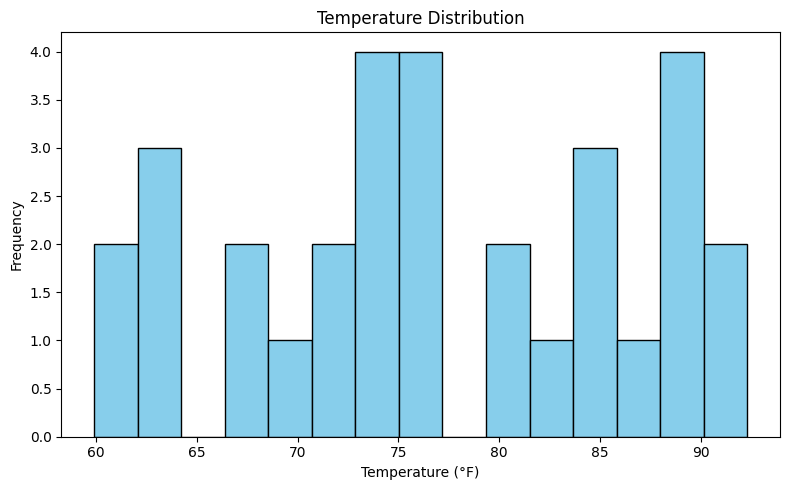

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(weather_df['Temp'], bins=15, color='skyblue', edgecolor='black')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')
plt.tight_layout()
plt.show()

## Temperature vs Humidity

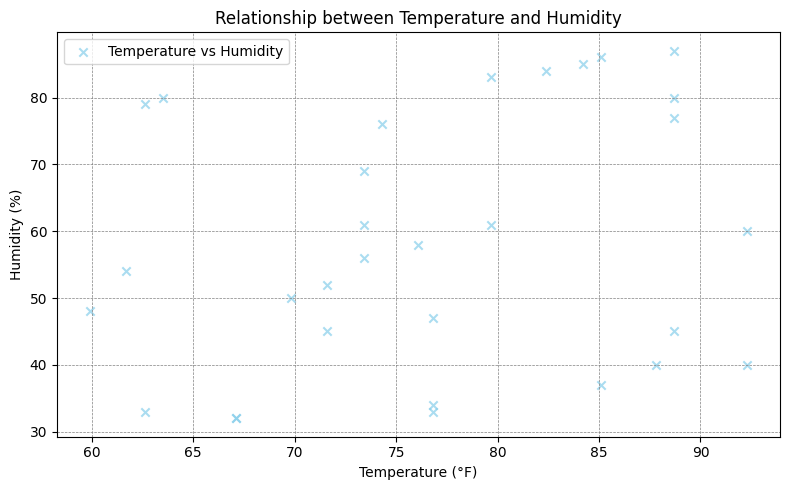

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(weather_df['Temp'], weather_df['Humidity'],
            color='skyblue', marker='x', alpha=0.7, label='Temperature vs Humidity')

plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.xlabel('Temperature (°F)')
plt.ylabel('Humidity (%)')
plt.title('Relationship between Temperature and Humidity')
plt.tight_layout()
plt.show()

## Correlation Between Temperature and Humidity

In [10]:
correlation = weather_df['Temp'].corr(weather_df['Humidity'])
print(f'Correlation coefficient: {correlation:.3f}')

Correlation coefficient: 0.231


## Humidity Distribution (Box Plot)

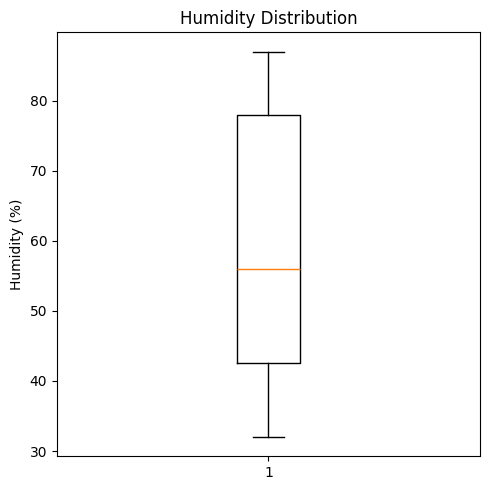

In [11]:
plt.figure(figsize=(5, 5))
plt.boxplot(weather_df['Humidity'].dropna())
plt.title('Humidity Distribution')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()